# 1. Introduction to ANN

An Artificial Neural Network (ANN) is a computational model inspired by the biological neural networks of the human brain. It consists of layers of interconnected "neurons" that process information and learn patterns from data.

**Setting Up the Environment**

First, we need to import the necessary libraries. We will use TensorFlow for the model, NumPy for math, and Matplotlib/Seaborn for visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Verify TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


**3. Data Acquisition and Preprocessing**

The MNIST dataset contains 60,000 training images and 10,000 testing images of 28x28 pixels.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


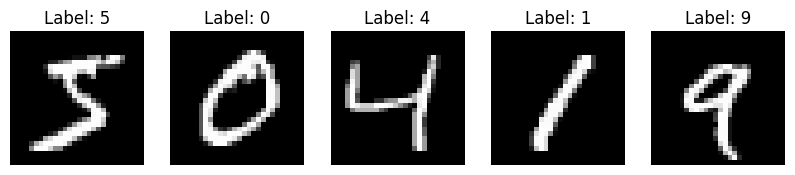

In [2]:
# Load the dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the pixel values (from 0-255 to 0-1)
# This helps the neural network converge faster.
x_train, x_test = x_train / 255.0, x_test / 255.0

# Visualizing the first 5 images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


**4. Building the Model Architecture**

We will create a Sequential model with three main parts:

Flatten Layer: Converts the 2D 28x28 image into a 1D 784-pixel vector.

Dense (Hidden) Layer: 128 neurons with 'ReLU' activation.

Output Layer: 10 neurons (one for each digit 0-9) with 'Softmax' activation.

In [3]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Flatten 28x28 to 784
    layers.Dense(128, activation='relu'),          # Hidden Layer
    layers.Dropout(0.2),                           # Dropout for regularization
    layers.Dense(10, activation='softmax')         # Output Layer (10 classes)
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**5. Training the Model**

We will train the model for 10 epochs and store the results in a history object for later visualization.

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9052 - loss: 0.3288 - val_accuracy: 0.9540 - val_loss: 0.1608
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9546 - loss: 0.1567 - val_accuracy: 0.9640 - val_loss: 0.1200
Epoch 3/10
1033/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9621 - loss: 0.1233

**Visual Representation Explanation:**

Accuracy Plot: If the training accuracy keeps rising while validation accuracy plateaus or drops, the model is overfitting.

Loss Plot: We want both lines to trend downwards. A gap between training and validation loss indicates the model's inability to generalize

In [ ]:
def plot_metrics(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_metrics(history)

7. Model Evaluation and Confusion Matrix

We evaluate the model on the unseen test set and visualize the errors using a Heatmap.

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')

# Predict classes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = tf.math.confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()


8. Making Predictions

Let's see the model in action by predicting a random image from the test set.

In [ ]:
index = 42 # Change this to see different results
plt.imshow(x_test[index], cmap='gray')
plt.title(f"True: {y_test[index]}, Predicted: {y_pred_classes[index]}")
plt.show()


**Deep Dive: Activation Functions**

Activation functions decide whether a neuron should be activated or not. They introduce non-linearity into the network, allowing it to learn complex patterns.

**Visual Representation Explanation:**

Sigmoid: Squeezes values between 0 and 1. Used in output layers for binary classification.

ReLU (Rectified Linear Unit): Outputs the input if it's positive, otherwise zero. It is the standard for hidden layers because it avoids the "vanishing gradient" problem.

Tanh: Squeezes values between -1 and 1. Often better than sigmoid for hidden layers as it is zero-centered.

`def tanh(x): return np.tanh(x)`
The Output: Similar to Sigmoid, but it squashes values between -1 and 1.

The Shape: A steeper "S" curve.

Use Case: Often used in Recurrent Neural Networks (RNNs) or when you want the data to be "zero-centered" (mean of 0), which can help the model converge faster during training.

In [ ]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x): return np.maximum(0, x)
def tanh(x): return np.tanh(x)

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 4))
plt.plot(x, sigmoid(x), label='Sigmoid', color='blue')
plt.plot(x, relu(x), label='ReLU', color='red')
plt.plot(x, tanh(x), label='Tanh', color='green')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Activation Functions Visualization")
plt.legend()
plt.grid(True)
plt.show()


**5. Building and Comparing Models**

We will now compare how different activation functions affect the learning of our MNIST model.

In [ ]:
def build_model(activation_func):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation=activation_func),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train with ReLU
print("Training with ReLU...")
history_relu = build_model('relu').fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=0)

# Train with Sigmoid
print("Training with Sigmoid...")
history_sig = build_model('sigmoid').fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=0)

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_relu.history['val_accuracy'], label='ReLU Val Acc', marker='o')
plt.plot(history_sig.history['val_accuracy'], label='Sigmoid Val Acc', marker='s')
plt.title('Impact of Activation Functions on Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Using the ReLU model for final evaluation
model = build_model('relu')
model.fit(x_train, y_train, epochs=5, verbose=0)

y_pred = np.argmax(model.predict(x_test), axis=1)
cm = tf.math.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (ReLU Model)')
plt.show()

**Exercises for Students:**

Hyperparameter Tuning: Change the number of neurons in the Dense layer (e.g., from 128 to 256) and observe the change in accuracy.

Activation Functions: Replace 'relu' with 'sigmoid' or 'tanh' and compare the training speed.

Layers: Add a second hidden layer to see if the model improves.

# Vanishing Gradient

Introduction

The Vanishing Gradient Problem occurs during the training of deep neural networks using gradient-based learning methods (like Backpropagation). As the gradient is propagated backward from the output layer to the input layer, it is multiplied by the derivatives of the activation functions.

If these derivatives are small (e.g., Sigmoid's maximum derivative is $0.25$), the gradient shrinks exponentially as it moves through many layers. Eventually, the weights of the initial layers change very little, and the network stops learning effectively.

2. Prerequisites

This lab uses:

NumPy: For numerical operations.

TensorFlow/Keras: To build and train the neural network.

Matplotlib/Seaborn: For plotting the gradient flow.

**Step 1: Import Libraries and Load Dataset**

We use the MNIST dataset of handwritten digits, which is a standard benchmark for testing neural network behavior.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
# This helps in faster convergence and stable gradients
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for the model (Flattening the 28x28 image to 784 vector)
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

print(f"Training data shape: {x_train.shape}")

Neural networks struggle with large input values; they prefer small numbers (usually 0 to 1 or -1 to 1). Dividing by 255.0 scales everything down. This prevents "exploding gradients" and helps the model learn much faster.

**Step 2: Creating a Deep Network to Induce Vanishing Gradients**

To see the problem, we will create an intentionally deep network (10+ layers) using the Sigmoid activation function.



*   layers.Input(shape=(784,)): This matches the flattened MNIST data from your previous snippet. It tells the model to expect 784 individual pixel values as input.
*   for i in range(10):
    
    model.add(layers.Dense(64, activation=activation_func))


This adds 10 identical layers, each with 64 neurons. This is unusually deep for a simple digit classifier and is specifically done to show how signals can "die out" as they move backward through many layers during training.



In [ ]:
def build_deep_model(activation_func='sigmoid'):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))

    # Adding 10 hidden layers to see the gradient decay
    for i in range(10):
        model.add(layers.Dense(64, activation=activation_func))

    model.add(layers.Dense(10, activation='softmax'))
    return model

sigmoid_model = build_deep_model('sigmoid')
relu_model = build_deep_model('relu')

sigmoid_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

**Step 3: Extracting Gradients for Visualization**

In Google Colab, we can use tf.GradientTape to manually calculate gradients and see how their magnitude changes across layers.

* tf.GradientTape(): This is the "record player" of TensorFlow. It records operations for automatic differentiation. It is essential for manually inspecting gradients.

* tape.gradient(loss, model.trainable_variables): This performs the backpropagation. It calculates $\frac{\partial Loss}{\partial Weight}$ for every single weight in the network.

* np.abs(g.numpy()): We take the absolute value because gradients can be negative or positive. We want to know the magnitude of the update.

* plt.yscale('log'): Since vanishing gradients involve exponential decay, a linear scale often makes the early layer gradients look like zero. The log scale reveals the true scale of the decay.

In [ ]:
def get_gradients(model, x_batch, y_batch):
    # Convert data to tensors
    x_batch = tf.cast(x_batch, tf.float32)

    with tf.GradientTape() as tape:
        # Forward pass
        predictions = model(x_batch)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_batch, predictions)

    # Calculate gradients of the loss with respect to all trainable variables
    gradients = tape.gradient(loss, model.trainable_variables)

    # We only care about weights (not biases) for this visualization
    # Weights are usually at even indices (0, 2, 4...) in model.trainable_variables
    weight_gradients = [grad for i, grad in enumerate(gradients) if i % 2 == 0]

    # Calculate mean absolute value of gradients per layer
    mean_grads = [np.mean(np.abs(g.numpy())) for g in weight_gradients]
    return mean_grads

In [ ]:
# Get a small batch of data
x_sample, y_sample = x_train[:100], y_train[:100]

# Extract gradients for both models
sig_grads = get_gradients(sigmoid_model, x_sample, y_sample)
relu_grads = get_gradients(relu_model, x_sample, y_sample)

**plt.yscale('log'):** Since vanishing gradients involve exponential decay, a linear scale often makes the early layer gradients look like zero. The log scale reveals the true scale of the decay.

Why? In a deep sigmoid network, the gradient at the last layer might be $0.1$, but at the first layer, it might be $0.0000001$.



*   The X-Axis (Layer Number): Represents the layers from the beginning of the network (Layer 1) to the end (Layer 11).
*   The Y-Axis (Gradient Magnitude): We use a Logarithmic Scale. This is crucial because the gradient for Sigmoid in the first layer might be $0.00001$ while in the last layer it is $0.1$.
*    The Sigmoid Curve (Red): You will notice a steep downward slope moving from right to left. The layers closest to the input (Layers 1-3) have extremely tiny gradients. This means the input layers "learn" almost nothing.
*    The ReLU Curve (Green): The line stays relatively flat or decays much more slowly. Because the derivative of ReLU is either $1$ or $0$, the gradient doesn't shrink simply by passing through the activation function.



In [ ]:
plt.figure(figsize=(12, 6))

# Plot Sigmoid Gradients
plt.plot(range(1, 12), sig_grads, marker='o', label='Sigmoid (Deep)', color='red')
# Plot ReLU Gradients
plt.plot(range(1, 12), relu_grads, marker='s', label='ReLU (Deep)', color='green')

plt.title('Gradient Magnitude per Layer (Vanishing Gradient Visualization)')
plt.xlabel('Layer Number (Input -> Output)')
plt.ylabel('Mean Absolute Gradient Value')
plt.yscale('log') # Log scale helps see the exponential decay
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()


# CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


In [ ]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Visualizing the dataset
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Step 2: Build the CNN Architecture**

We will use a stack of Conv2D and MaxPooling2D layers.

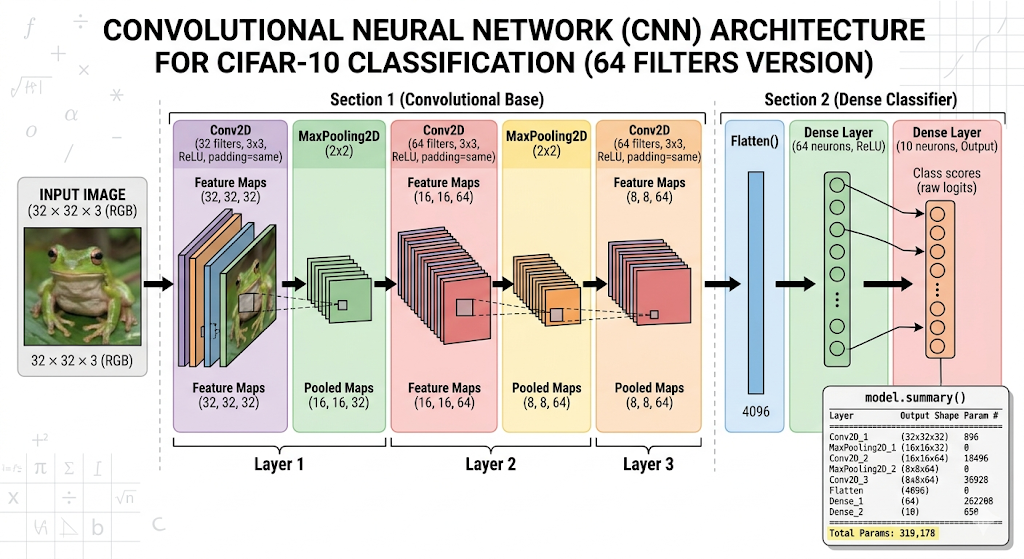

In [ ]:
model = models.Sequential()

# Layer 1: Convolution + ReLU + Pooling
# 32 filters of size 3x3. 'padding=same' keeps dimensions 32x32.
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2))) # Reduces size to 16x16

# Layer 2: Deeper features
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2))) # Reduces size to 8x8

# Layer 3:
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))

# Adding Dense Layers for Classification
model.add(layers.Flatten()) # Converts 3D feature map to 1D vector
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # 10 output units for 10 classes

model.summary()

**Step 3: Compile and Train**

We use Adam optimizer and SparseCategoricalCrossentropy (since labels are integers).

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

**Step 4: Visualizing Training Performance**

Graphs are essential to check for overfitting.

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Model Accuracy over Epochs')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')

**Perform the Experiments**

* Learning Rate Impact: Change LEARNING_RATE to 0.1 and observe how the accuracy fails to improve (overshooting). Then try 0.0001 and see how much slower the accuracy rises.

* Deepening the Network: Add one more Conv2D layer with 128 filters before the Flatten layer and see if accuracy improves.